<a href="https://colab.research.google.com/github/preethi3076/Market-Maker-project/blob/main/Market_Maker_Simulator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Intraday Market-Making Simulator
**Description:** A rule-based liquidity provision engine for futures contracts. Implements dynamic bid/ask quoting with inventory skewing (Avellaneda-Stoikov style), position limits, and a rolling-volatility kill-switch to mitigate adverse selection.



In [67]:
import yfinance as yf
import pandas as pd
import numpy as np

# 1. Fetch raw data
df = yf.download(tickers="CL=F", period="5d", interval="5m", progress=False)

# 2. Rip out the MultiIndex and flatten the columns
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# 3. Pull Datetime out of the index so it's a normal column
df = df.reset_index()

# 4. Force all columns to lowercase and rename Datetime to timestamp
df = df.rename(columns={
    'Datetime': 'timestamp',
    'Date': 'timestamp',
    'Open': 'open',
    'High': 'high',
    'Low': 'low',
    'Close': 'close',
    'Volume': 'volume'
})

# 5. Drop any weird columns or missing data and reset integer index
df = df[['timestamp', 'open', 'high', 'low', 'close', 'volume']].dropna().reset_index(drop=True)

# 6. Calculate rolling returns for our kill-switch later
df['returns'] = df['close'].pct_change()

print("Data perfectly cleaned! Check the columns:")
print(df.columns)


/tmp/ipykernel_4800/2982088093.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers="CL=F", period="5d", interval="5m", progress=False)


Data perfectly cleaned! Check the columns:
Index(['timestamp', 'open', 'high', 'low', 'close', 'volume', 'returns'], dtype='object', name='Price')


In [68]:
df = fetch_intraday_futures_data()
df.head()


Fetching5d of 5m data for ticker:CL=F..


/tmp/ipykernel_4800/3760005913.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers=ticker, period = period , interval = interval,progress = False )


Price,Close,High,Low,Open,Volume
Ticker,CL=F,CL=F,CL=F,CL=F,CL=F
Datetime,,,,,
2026-08-17 04:00:00+00:00,82.010002,82.199997,81.940002,82.169998,0
2026-08-17 04:05:00+00:00,82.139999,82.139999,81.989998,82.019997,217
2026-08-17 04:10:00+00:00,82.089996,82.129997,82.040001,82.120003,96
2026-08-17 04:15:00+00:00,82.209999,82.230003,82.070000,82.070000,147
2026-08-17 04:20:00+00:00,82.269997,82.269997,82.180000,82.180000,76


In [69]:
class MarketMakerSimulator:
    def __init__(self, data_df, spread=0.50, max_inventory=10,
                 skew_per_lot=0.05, vol_window=12, vol_threshold=0.004,
                 lot_size=1, transaction_cost=0.02):

        self.df = data_df.copy().reset_index(drop=True)

        # Market Making Rules
        self.spread = spread                  # How much profit we try to make per trade
        self.max_inventory = max_inventory    # Don't hold more than 10 lots (Risk Management)
        self.skew_per_lot = skew_per_lot      # Shift our quotes based on inventory

        # Risk Limits
        self.vol_window = vol_window          # Look at last 12 bars (1 hour)
        self.vol_threshold = vol_threshold    # If volatility is > 0.4%, stop trading

        # Costs
        self.lot_size = lot_size
        self.transaction_cost = transaction_cost

        # Calculate Rolling Volatility for the Kill-Switch
        self.df['returns'] = self.df['close'].pct_change()
        self.df['rolling_vol'] = self.df['returns'].rolling(window=self.vol_window, min_periods=1).std()

    def run_simulation(self):
        n = len(self.df)

        # Trackers for our performance
        inventory = np.zeros(n)
        bid_quotes = np.zeros(n)
        ask_quotes = np.zeros(n)
        kill_switch_active = np.zeros(n, dtype=bool)

        current_inv = 0

        # Loop through every single 5-minute candle
        for i in range(n - 1):
            close_price = self.df.loc[i, 'close']
            vol = self.df.loc[i, 'rolling_vol']

            # 1. The Kill-Switch: If volatility is crazy, step away
            if not np.isnan(vol) and vol > self.vol_threshold:
                kill_switch_active[i] = True
                bid_quotes[i] = np.nan
                ask_quotes[i] = np.nan
            else:
                # 2. Inventory Skewing: Shift our target mid-price
                skew = current_inv * self.skew_per_lot
                mid = close_price - skew
                half_spread = self.spread / 2.0

                # 3. Position Limits: Don't buy/sell if we hit our max limits
                if current_inv >= self.max_inventory:
                    bid_quotes[i] = np.nan  # Stop bidding
                    ask_quotes[i] = mid + half_spread
                elif current_inv <= -self.max_inventory:
                    bid_quotes[i] = mid - half_spread
                    ask_quotes[i] = np.nan  # Stop asking
                else:
                    # Normal quoting on both sides
                    bid_quotes[i] = mid - half_spread
                    ask_quotes[i] = mid + half_spread

        print("Engine logic loaded and quotes generated!")

In [70]:
    def run_simulation(self):
        n = len(self.df)

        # Trackers for our performance
        inventory = np.zeros(n)
        bid_quotes = np.zeros(n)
        ask_quotes = np.zeros(n)
        kill_switch_active = np.zeros(n, dtype=bool)

        current_inv = 0

        # Loop through every single 5-minute candle
        for i in range(n - 1):
            close_price = self.df.loc[i, 'close']
            vol = self.df.loc[i, 'rolling_vol']

            # 1. The Kill-Switch: If volatility is crazy, step away
            if not np.isnan(vol) and vol > self.vol_threshold:
                kill_switch_active[i] = True
                bid_quotes[i] = np.nan
                ask_quotes[i] = np.nan
            else:
                # 2. Inventory Skewing: Shift our target mid-price
                skew = current_inv * self.skew_per_lot
                mid = close_price - skew
                half_spread = self.spread / 2.0

                # 3. Position Limits: Don't buy/sell if we hit our max limits
                if current_inv >= self.max_inventory:
                    bid_quotes[i] = np.nan  # Stop bidding
                    ask_quotes[i] = mid + half_spread
                elif current_inv <= -self.max_inventory:
                    bid_quotes[i] = mid - half_spread
                    ask_quotes[i] = np.nan  # Stop asking
                else:
                    # Normal quoting on both sides
                    bid_quotes[i] = mid - half_spread
                    ask_quotes[i] = mid + half_spread

        print("Engine logic loaded and quotes generated!")


In [71]:
import yfinance as yf
import pandas as pd
import numpy as np

# 1. Fetch fresh data
df = yf.download(tickers="CL=F", period="5d", interval="5m", progress=False)

# 2. Clean it
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)
df = df.reset_index()
df = df.rename(columns={'Datetime': 'timestamp', 'Date': 'timestamp',
                        'Open': 'open', 'High': 'high', 'Low': 'low',
                        'Close': 'close', 'Volume': 'volume'})
df = df[['timestamp', 'open', 'high', 'low', 'close', 'volume']].dropna().reset_index(drop=True)
df['returns'] = df['close'].pct_change()
print("Data is fresh and clean.")


/tmp/ipykernel_4800/2807946471.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers="CL=F", period="5d", interval="5m", progress=False)


Data is fresh and clean.


In [72]:
import numpy as np

class MarketMakerSimulator:
    def __init__(self, data_df, spread=0.50, max_inventory=10,
                 skew_per_lot=0.05, vol_window=12, vol_threshold=0.004,
                 lot_size=1, transaction_cost=0.02):
        self.df = data_df.copy().reset_index(drop=True)
        self.spread = spread
        self.max_inventory = max_inventory
        self.skew_per_lot = skew_per_lot
        self.vol_window = vol_window
        self.vol_threshold = vol_threshold
        self.lot_size = lot_size
        self.transaction_cost = transaction_cost

        self.df['returns'] = self.df['close'].pct_change()
        self.df['rolling_vol'] = self.df['returns'].rolling(window=self.vol_window, min_periods=1).std()

    def run_simulation(self):
        n = len(self.df)
        inventory = np.zeros(n)
        realized_pnl = np.zeros(n)
        unrealized_pnl = np.zeros(n)
        total_pnl = np.zeros(n)
        spread_pnl = np.zeros(n)

        bid_quotes = np.zeros(n)
        ask_quotes = np.zeros(n)
        kill_switch_active = np.zeros(n, dtype=bool)

        current_inv = 0
        cum_spread_pnl = 0.0
        cum_realized_pnl = 0.0
        inventory_cost_basis = 0.0

        for i in range(n - 1):
            close_price = self.df.loc[i, 'close']
            vol = self.df.loc[i, 'rolling_vol']

            # Kill switch
            if not np.isnan(vol) and vol > self.vol_threshold:
                kill_switch_active[i] = True
                bid_quotes[i] = np.nan
                ask_quotes[i] = np.nan
            else:
                # Skew quotes
                skew = current_inv * self.skew_per_lot
                mid = close_price - skew
                half_spread = self.spread / 2.0

                if current_inv >= self.max_inventory:
                    bid_quotes[i] = np.nan
                    ask_quotes[i] = mid + half_spread
                elif current_inv <= -self.max_inventory:
                    bid_quotes[i] = mid - half_spread
                    ask_quotes[i] = np.nan
                else:
                    bid_quotes[i] = mid - half_spread
                    ask_quotes[i] = mid + half_spread

            next_low = self.df.loc[i + 1, 'low']
            next_high = self.df.loc[i + 1, 'high']

            # Executions
            if not np.isnan(bid_quotes[i]) and next_low <= bid_quotes[i]:
                exec_price = bid_quotes[i]
                current_inv += 1
                if current_inv <= 0:
                    trade_pnl = (inventory_cost_basis - exec_price - self.transaction_cost) * self.lot_size
                    cum_realized_pnl += trade_pnl
                    cum_spread_pnl += (self.spread / 2.0 - self.transaction_cost) * self.lot_size
                else:
                    inventory_cost_basis = exec_price

            if not np.isnan(ask_quotes[i]) and next_high >= ask_quotes[i]:
                exec_price = ask_quotes[i]
                current_inv -= 1
                if current_inv >= 0:
                    trade_pnl = (exec_price - inventory_cost_basis - self.transaction_cost) * self.lot_size
                    cum_realized_pnl += trade_pnl
                    cum_spread_pnl += (self.spread / 2.0 - self.transaction_cost) * self.lot_size
                else:
                    inventory_cost_basis = exec_price

            inventory[i + 1] = current_inv
            realized_pnl[i + 1] = cum_realized_pnl
            spread_pnl[i + 1] = cum_spread_pnl

            next_close = self.df.loc[i + 1, 'close']
            if current_inv != 0:
                unrealized_pnl[i + 1] = current_inv * (next_close - inventory_cost_basis) * self.lot_size
            else:
                unrealized_pnl[i + 1] = 0.0

            total_pnl[i + 1] = realized_pnl[i + 1] + unrealized_pnl[i + 1]

        res = self.df.copy()
        res['inventory'] = inventory
        res['total_pnl'] = total_pnl
        res['spread_pnl'] = spread_pnl
        res['unrealized_pnl'] = unrealized_pnl

        return res


In [73]:
sim = MarketMakerSimulator(df)
results = sim.run_simulation()
print(results[['timestamp', 'close', 'inventory', 'total_pnl']].tail(10))



Price                 timestamp      close  inventory  total_pnl
1298  2026-08-21 20:10:00+00:00  86.660004        0.0  10.879991
1299  2026-08-21 20:15:00+00:00  86.709999        0.0  10.879991
1300  2026-08-21 20:20:00+00:00  86.800003        0.0  10.879991
1301  2026-08-21 20:25:00+00:00  86.849998        0.0  10.879991
1302  2026-08-21 20:30:00+00:00  86.769997        0.0  10.879991
1303  2026-08-21 20:35:00+00:00  86.779999        0.0  10.879991
1304  2026-08-21 20:40:00+00:00  86.820000        0.0  10.879991
1305  2026-08-21 20:45:00+00:00  86.699997        0.0  10.879991
1306  2026-08-21 20:50:00+00:00  86.680000        0.0  10.879991
1307  2026-08-21 20:55:00+00:00  87.059998       -1.0  10.749994


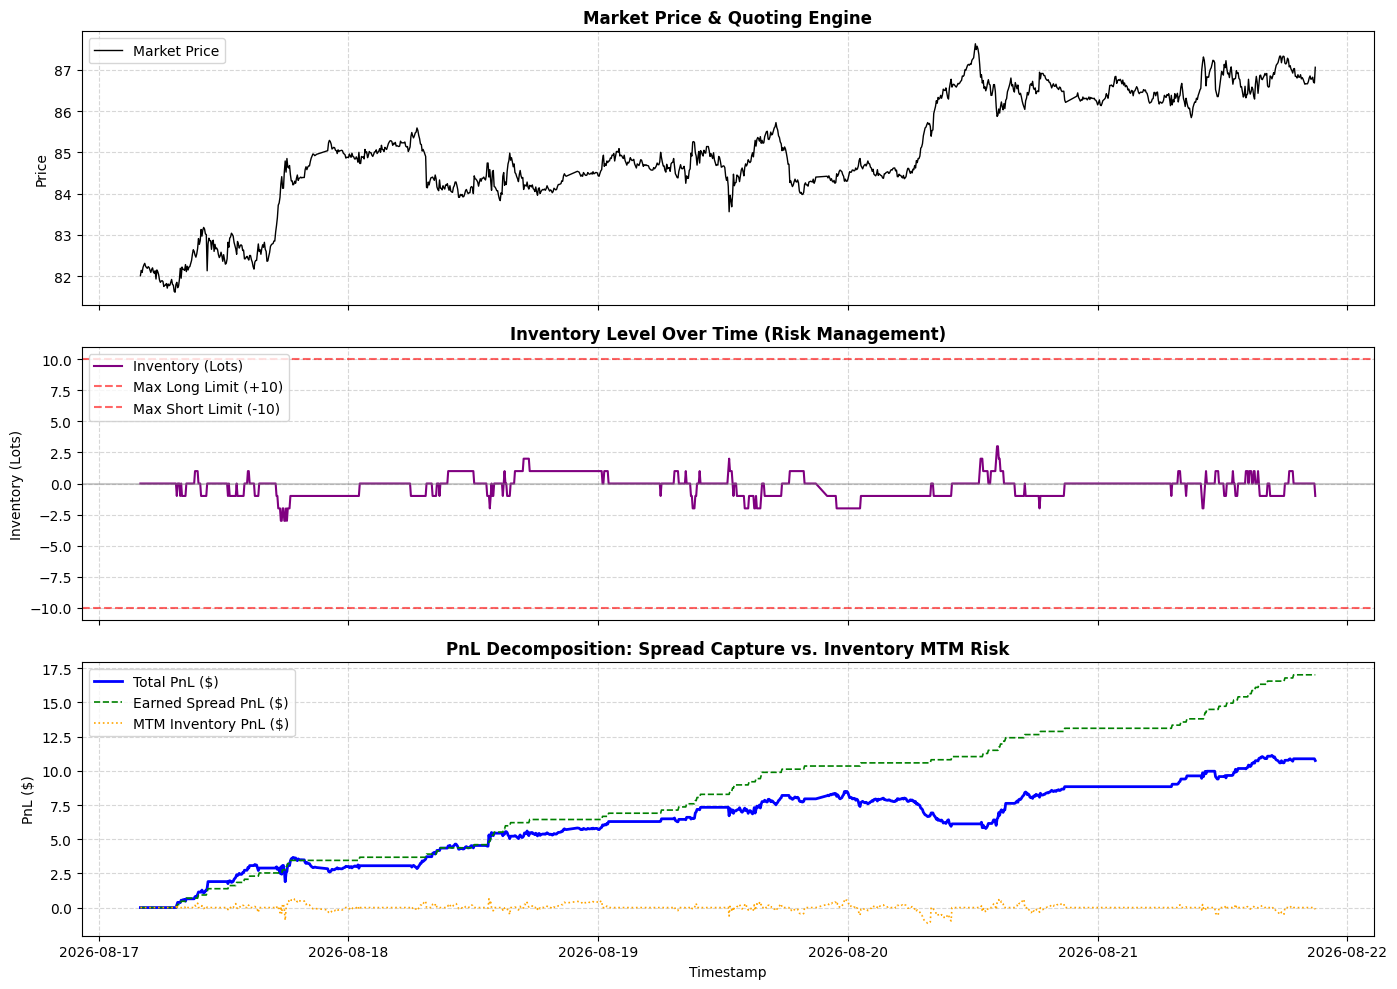

In [74]:
import matplotlib.pyplot as plt

# Create a massive 3-panel chart
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Panel 1: Market Price & Volatility Kill-Switch tracker
axes[0].plot(results['timestamp'], results['close'], color='black', label='Market Price', linewidth=1)
axes[0].set_title('Market Price & Quoting Engine', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Price', fontsize=10)

# Panel 2: Inventory Risk Management
axes[1].plot(results['timestamp'], results['inventory'], color='purple', linewidth=1.5, label='Inventory (Lots)')
axes[1].axhline(10, color='red', linestyle='--', alpha=0.6, label='Max Long Limit (+10)')
axes[1].axhline(-10, color='red', linestyle='--', alpha=0.6, label='Max Short Limit (-10)')
axes[1].axhline(0, color='gray', linestyle='-', alpha=0.4)
axes[1].set_title('Inventory Level Over Time (Risk Management)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Inventory (Lots)', fontsize=10)

# Panel 3: PnL Decomposition (The Money Maker)
axes[2].plot(results['timestamp'], results['total_pnl'], color='blue', linewidth=2, label='Total PnL ($)')
axes[2].plot(results['timestamp'], results['spread_pnl'], color='green', linewidth=1.2, linestyle='--', label='Earned Spread PnL ($)')
axes[2].plot(results['timestamp'], results['unrealized_pnl'], color='orange', linewidth=1.2, linestyle=':', label='MTM Inventory PnL ($)')
axes[2].set_title('PnL Decomposition: Spread Capture vs. Inventory MTM Risk', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Timestamp', fontsize=10)
axes[2].set_ylabel('PnL ($)', fontsize=10)

# Apply formatting
for ax in axes:
    ax.legend(loc='upper left')
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
